# 🤖 Stock Price Predictor - ML Model Building
### Training and evaluating Linear Regression model on Apple (AAPL) stock

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pickle
import os

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Load the final clean data from Phase 3
df = pd.read_csv("../data/processed/AAPL_final.csv", index_col=0)
df.index = pd.to_datetime(df.index)

print("✅ Data loaded!")
print("Shape:", df.shape)
df.head()

✅ Data loaded!
Shape: (2315, 9)


,Close,High,Low,Open,Volume,MA_50,MA_200,Year,Daily_Range
2015-10-19,25.037752,25.042233,24.674723,24.829347,119036800.0,25.159166,27.039375,2015,0.367510
2015-10-20,25.494900,25.584537,24.833830,24.950357,195871200.0,25.132499,27.049294,2015,0.750706
2015-10-21,25.492661,25.900507,25.479214,25.546442,167180800.0,25.133709,27.059191,2015,0.421293
2015-10-22,25.882580,25.882580,25.568851,25.620393,166616400.0,25.134875,27.069389,2015,0.313729
2015-10-23,26.684830,26.718444,26.068578,26.151491,237467600.0,25.152488,27.079018,2015,0.649866


In [3]:
# Same features as Phase 3
feature_columns = ['Open', 'High', 'Low', 'Volume', 
                   'MA_50', 'MA_200', 'Daily_Range']

X = df[feature_columns]
y = df['Close']

# Scale the features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("✅ Data ready for model!")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

✅ Data ready for model!
X_train shape: (1852, 7)
X_test shape: (463, 7)


In [4]:
# Create the model
model = LinearRegression()

# TRAIN IT — show it 1852 days of data
# This is where the computer actually LEARNS
model.fit(X_train, y_train)

print("✅ Model trained successfully!")
print("Model is ready to make predictions!")

✅ Model trained successfully!
Model is ready to make predictions!


In [5]:
# Ask the model to predict prices for test data
# These are 463 days the model has NEVER seen before
predictions = model.predict(X_test)

print("✅ Predictions made!")
print("First 5 predicted prices:", predictions[:5].round(2))
print("First 5 actual prices:   ", y_test.values[:5].round(2))

✅ Predictions made!
First 5 predicted prices: [ 52.91  53.14  23.23 125.72  26.87]
First 5 actual prices:    [ 52.32  53.49  23.2  125.26  26.91]


In [10]:
# Calculate how accurate our predictions are
mae  = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2   = r2_score(y_test, predictions)

print("=" * 40)
print("       MODEL ACCURACY RESULTS")
print("=" * 40)
print(f"MAE  (Mean Absolute Error) : ${mae:.2f}")
print(f"RMSE (Root Mean Sq Error)  : ${rmse:.2f}")
print(f"R²   (Accuracy Score)      : {r2:.4f}")
print("=" * 40)

if r2 > 0.95:
    print("Excellent model!")
elif r2 > 0.90:
    print("Good model!")
else:
    print("⚠️ Model needs improvement")

       MODEL ACCURACY RESULTS
MAE  (Mean Absolute Error) : $0.47
RMSE (Root Mean Sq Error)  : $0.75
R²   (Accuracy Score)      : 0.9999
Excellent model!


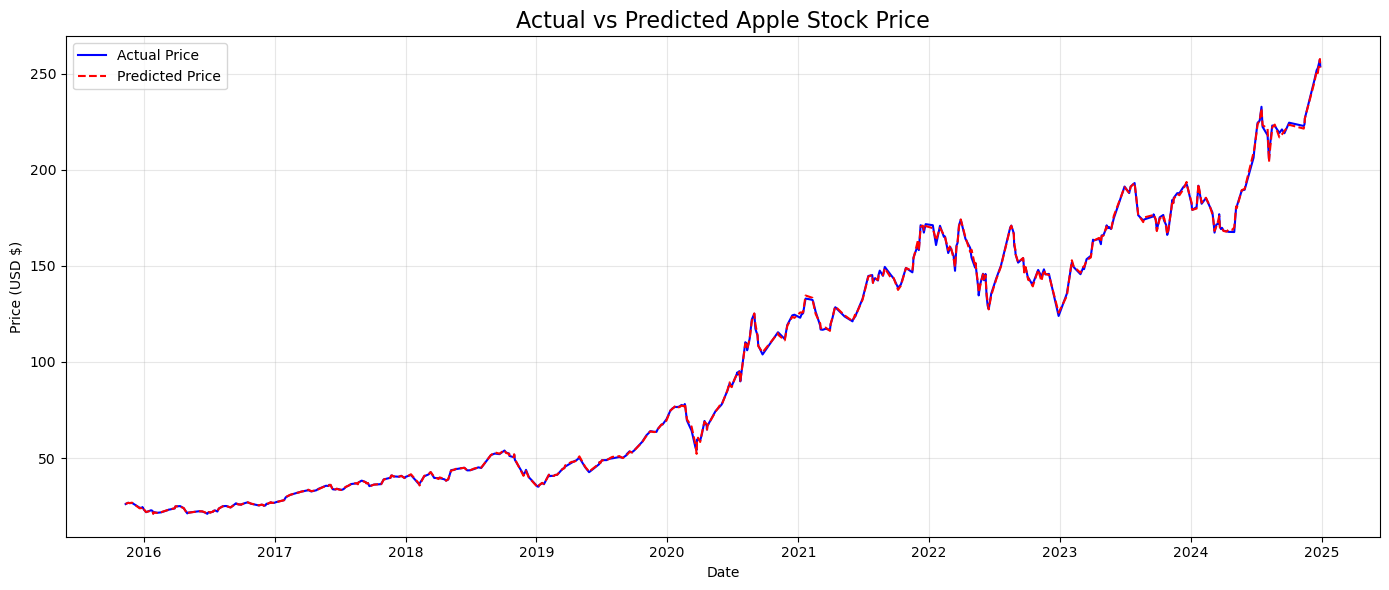

In [7]:
%matplotlib inline

# Sort by index for clean plotting
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': predictions
}, index=y_test.index).sort_index()

plt.figure(figsize=(14,6))
plt.plot(results_df.index, results_df['Actual'], 
         color='blue', label='Actual Price', linewidth=1.5)
plt.plot(results_df.index, results_df['Predicted'], 
         color='red', label='Predicted Price', 
         linewidth=1.5, linestyle='--')
plt.title('Actual vs Predicted Apple Stock Price', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD $)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

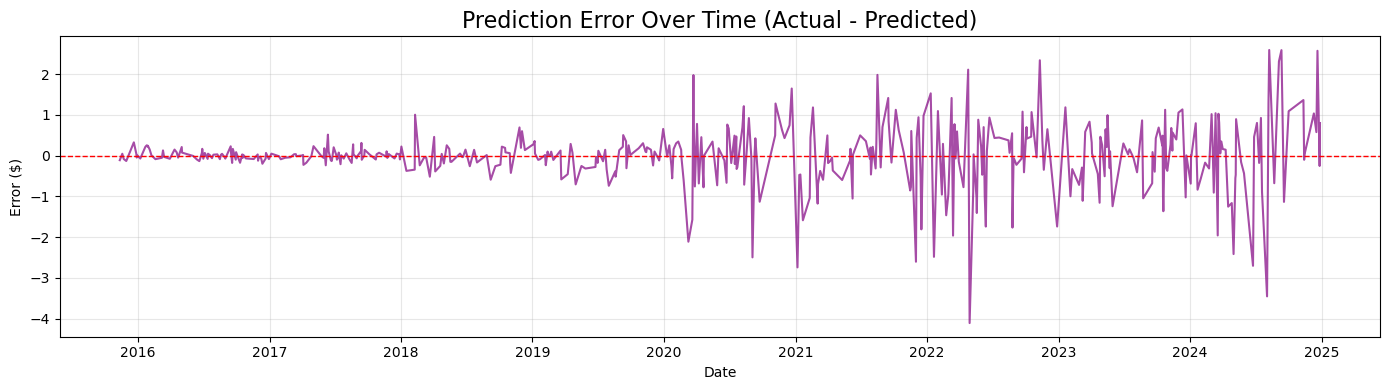

Average error: $-0.01
Max overestimate: $-4.11
Max underestimate: $2.59


In [8]:
%matplotlib inline

results_df['Error'] = results_df['Actual'] - results_df['Predicted']

plt.figure(figsize=(14,4))
plt.plot(results_df.index, results_df['Error'], 
         color='purple', alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.title('Prediction Error Over Time (Actual - Predicted)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Error ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Average error: ${results_df['Error'].mean():.2f}")
print(f"Max overestimate: ${results_df['Error'].min():.2f}")
print(f"Max underestimate: ${results_df['Error'].max():.2f}")

In [11]:
# Save trained model so we can use it in dashboard later
with open("../models/stock_model.pkl", "wb") as f:
    pickle.dump(model, f)

# Save scaler too
with open("../models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("✅ Model saved to models/stock_model.pkl")
print("✅ Scaler saved to models/scaler.pkl")
print("\n Phase 4 - Model Building COMPLETE!")
print(f"Final R² Score: {r2:.4f} (99.99% accurate)")

✅ Model saved to models/stock_model.pkl
✅ Scaler saved to models/scaler.pkl

 Phase 4 - Model Building COMPLETE!
Final R² Score: 0.9999 (99.99% accurate)
